In [1]:
import os
from pathlib import Path

baselines_fleetsdeg = 'baselines_fleetsdeg' 
testfolder = 'Sims'

if not os.path.exists(testfolder):
    os.makedirs(testfolder)

if not os.path.exists(baselines_fleetsdeg):
    os.makedirs(baselines_fleetsdeg)

In [2]:
import PV_ICE

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({'font.size': 14})
plt.rcParams['figure.figsize'] = (12, 5)

In [4]:
# This information helps with debugging and getting support :)
import sys, platform
from datetime import date

print("DATE: ", date.today())
print("Working on a ", platform.system(), platform.release())
print("Python version ", sys.version)
print("Pandas version ", pd.__version__)
print("PV_ICE version ", PV_ICE.__version__)


DATE:  2026-01-14
Working on a  Windows 11
Python version  3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
Pandas version  2.2.3
PV_ICE version  0.2.1.dev686+gfb6f99a63


In [5]:
US_base_dir = r'C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\baselines'
US_baseline_file = 'baseline_modules_mass_US_Si.csv' # 'baseline_modules_mass_US_updatedT50T90.csv'
US_baseline_file_CdTe = 'baseline_modules_mass_US_CdTe.csv'
degradation_file = r'PVFleets_Degradation_Data.csv' # same folder

out_dir = 'baselines_fleetsdeg'

In [6]:
# SI First
baseline_path = os.path.join(US_base_dir, US_baseline_file)

# --- Read baseline ---
df_raw = pd.read_csv(baseline_path)
columns_order = df_raw.columns.tolist()
units_row = df_raw.iloc[0:1].copy()          # exact units row as in source

deg = pd.read_csv(degradation_file, sep=None, engine='python')


capacity_col  = 'new_Installed_Capacity_[MW]'
year_col  = 'year'

# Normalize column names (strip spaces, unify)
deg.columns = [c.strip() for c in deg.columns]
# Handle common header variants
rename_map = {}
for c in deg.columns:
    if 'Degradation' in c and 'Rate' in c:
        rename_map[c] = 'deg_rate'
    if '%' in c and ('Cohort' in c or 'cohort' in c):
        rename_map[c] = 'cohort_pct'
deg = deg.rename(columns=rename_map)

# Clean types
deg['deg_rate'] = pd.to_numeric(deg['deg_rate'], errors='coerce')
deg['cohort_pct'] = pd.to_numeric(deg['cohort_pct'], errors='coerce')
deg = deg.dropna(subset=['deg_rate', 'cohort_pct'])

# Work on a cleaned copy for math
df_base = df_raw.iloc[1:].copy()

# Coerce numerics to drop non-numeric rows (like the units row) for calculations
df_base[year_col] = pd.to_numeric(df_base[year_col], errors='coerce')
df_base[capacity_col] = pd.to_numeric(df_base[capacity_col], errors='coerce')

# --- Helper: prepend units row and enforce original column order ---
def finalize_with_units(df_calc: pd.DataFrame) -> pd.DataFrame:
    # Reorder to original columns (plus any new ones we ensured in units_row)
    df_calc = df_calc.reindex(columns=columns_order)
    # Align units row to same columns
    units_aligned = units_row.reindex(columns=columns_order)
    # Prepend units row exactly as it appeared
    out = pd.concat([units_aligned, df_calc], ignore_index=True)
    return out

year_num = pd.to_numeric(df_raw[year_col], errors='coerce')
mask_startyear = year_num >= 2017

saved_files = []

for _, row in deg.iterrows():
    rate = float(row['deg_rate'])        # typically negative in PV Fleets (e.g., -2.0 %/yr)
    pct = float(row['cohort_pct'])       # in percent (e.g., 5.0 means 5%)

    df_cohort = df_base.copy()

    # Scale the installed capacity by the cohort share
    df_cohort[capacity_col] = df_cohort[capacity_col] * (pct / 100.0)

    # Set mod_degradation to the positive number (e.g., 2.0 for -2.0), per your example
    df_cohort.loc[mask_startyear, 'mod_degradation'] = abs(rate)

    # Save per-cohort file
    base_name = "baseline_modules_mass_Si"   # no .csv, just the stem
    out_name = f"{base_name}__cohort_{pct:0.2f}pct__deg_{abs(rate):0.1f}.csv"
    df_out = finalize_with_units(df_cohort)
    out_path = os.path.join(out_dir, out_name)
    df_out.to_csv(out_path, index=False)
    saved_files.append(Path(out_path).stem)

saved_files

['baseline_modules_mass_Si__cohort_0.18pct__deg_5.2',
 'baseline_modules_mass_Si__cohort_0.59pct__deg_4.2',
 'baseline_modules_mass_Si__cohort_1.04pct__deg_3.4',
 'baseline_modules_mass_Si__cohort_0.45pct__deg_3.2',
 'baseline_modules_mass_Si__cohort_0.57pct__deg_3.0',
 'baseline_modules_mass_Si__cohort_0.73pct__deg_2.8',
 'baseline_modules_mass_Si__cohort_1.12pct__deg_2.6',
 'baseline_modules_mass_Si__cohort_1.36pct__deg_2.4',
 'baseline_modules_mass_Si__cohort_2.34pct__deg_2.2',
 'baseline_modules_mass_Si__cohort_3.50pct__deg_2.0',
 'baseline_modules_mass_Si__cohort_4.70pct__deg_1.8',
 'baseline_modules_mass_Si__cohort_5.37pct__deg_1.6',
 'baseline_modules_mass_Si__cohort_6.90pct__deg_1.4',
 'baseline_modules_mass_Si__cohort_8.51pct__deg_1.2',
 'baseline_modules_mass_Si__cohort_10.22pct__deg_1.0',
 'baseline_modules_mass_Si__cohort_11.62pct__deg_0.8',
 'baseline_modules_mass_Si__cohort_12.30pct__deg_0.6',
 'baseline_modules_mass_Si__cohort_10.06pct__deg_0.4',
 'baseline_modules_mass_

In [7]:
# SI First
baseline_path = os.path.join(US_base_dir, US_baseline_file_CdTe)

# --- Read baseline ---
df_raw = pd.read_csv(baseline_path)
columns_order = df_raw.columns.tolist()
units_row = df_raw.iloc[0:1].copy()          # exact units row as in source

deg = pd.read_csv(degradation_file, sep=None, engine='python')


capacity_col  = 'new_Installed_Capacity_[MW]'
year_col  = 'year'

# Normalize column names (strip spaces, unify)
deg.columns = [c.strip() for c in deg.columns]
# Handle common header variants
rename_map = {}
for c in deg.columns:
    if 'Degradation' in c and 'Rate' in c:
        rename_map[c] = 'deg_rate'
    if '%' in c and ('Cohort' in c or 'cohort' in c):
        rename_map[c] = 'cohort_pct'
deg = deg.rename(columns=rename_map)

# Clean types
deg['deg_rate'] = pd.to_numeric(deg['deg_rate'], errors='coerce')
deg['cohort_pct'] = pd.to_numeric(deg['cohort_pct'], errors='coerce')
deg = deg.dropna(subset=['deg_rate', 'cohort_pct'])

# Work on a cleaned copy for math
df_base = df_raw.iloc[1:].copy()

# Coerce numerics to drop non-numeric rows (like the units row) for calculations
df_base[year_col] = pd.to_numeric(df_base[year_col], errors='coerce')
df_base[capacity_col] = pd.to_numeric(df_base[capacity_col], errors='coerce')

# --- Helper: prepend units row and enforce original column order ---
def finalize_with_units(df_calc: pd.DataFrame) -> pd.DataFrame:
    # Reorder to original columns (plus any new ones we ensured in units_row)
    df_calc = df_calc.reindex(columns=columns_order)
    # Align units row to same columns
    units_aligned = units_row.reindex(columns=columns_order)
    # Prepend units row exactly as it appeared
    out = pd.concat([units_aligned, df_calc], ignore_index=True)
    return out

year_num = pd.to_numeric(df_raw[year_col], errors='coerce')
mask_startyear = year_num >= 2017

saved_files_CdTE = []

for _, row in deg.iterrows():
    rate = float(row['deg_rate'])        # typically negative in PV Fleets (e.g., -2.0 %/yr)
    pct = float(row['cohort_pct'])       # in percent (e.g., 5.0 means 5%)

    df_cohort = df_base.copy()

    # Scale the installed capacity by the cohort share
    df_cohort[capacity_col] = df_cohort[capacity_col] * (pct / 100.0)

    # Set mod_degradation to the positive number (e.g., 2.0 for -2.0), per your example
    df_cohort.loc[mask_startyear, 'mod_degradation'] = abs(rate)

    # Save per-cohort file
    base_name = "baseline_modules_mass_CdTe"   # no .csv, just the stem
    out_name = f"{base_name}__cohort_{pct:0.2f}pct__deg_{abs(rate):0.1f}.csv"
    df_out = finalize_with_units(df_cohort)
    out_path = os.path.join(out_dir, out_name)
    df_out.to_csv(out_path, index=False)
    saved_files_CdTE.append(Path(out_path).stem)

saved_files_CdTE

['baseline_modules_mass_CdTe__cohort_0.18pct__deg_5.2',
 'baseline_modules_mass_CdTe__cohort_0.59pct__deg_4.2',
 'baseline_modules_mass_CdTe__cohort_1.04pct__deg_3.4',
 'baseline_modules_mass_CdTe__cohort_0.45pct__deg_3.2',
 'baseline_modules_mass_CdTe__cohort_0.57pct__deg_3.0',
 'baseline_modules_mass_CdTe__cohort_0.73pct__deg_2.8',
 'baseline_modules_mass_CdTe__cohort_1.12pct__deg_2.6',
 'baseline_modules_mass_CdTe__cohort_1.36pct__deg_2.4',
 'baseline_modules_mass_CdTe__cohort_2.34pct__deg_2.2',
 'baseline_modules_mass_CdTe__cohort_3.50pct__deg_2.0',
 'baseline_modules_mass_CdTe__cohort_4.70pct__deg_1.8',
 'baseline_modules_mass_CdTe__cohort_5.37pct__deg_1.6',
 'baseline_modules_mass_CdTe__cohort_6.90pct__deg_1.4',
 'baseline_modules_mass_CdTe__cohort_8.51pct__deg_1.2',
 'baseline_modules_mass_CdTe__cohort_10.22pct__deg_1.0',
 'baseline_modules_mass_CdTe__cohort_11.62pct__deg_0.8',
 'baseline_modules_mass_CdTe__cohort_12.30pct__deg_0.6',
 'baseline_modules_mass_CdTe__cohort_10.06pct

In [8]:
out_dir

'baselines_fleetsdeg'

In [9]:
import re
deg_parts = [re.search(r'(deg_[^_]+)$', n).group(1) for n in saved_files if re.search(r'(deg_[^_]+)$', n)]


In [10]:
r1 = PV_ICE.Simulation(name='Sim1', path=testfolder)

path = Sims
Baseline folder directed to default:  C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\baselines


In [11]:
r1.createScenario(name='base_Si', massmodulefile='baseline_modules_mass_US_Si.csv', energymodulefile='baseline_modules_energy.csv')
r1.scenario['base_Si'].addMaterials(['glass', 'silicon', 'silver', 'copper', 'aluminium_frames', 'encapsulant'])


Adding Mass AND Energy files for:  glass
Adding Mass AND Energy files for:  silicon
Adding Mass AND Energy files for:  silver
Adding Mass AND Energy files for:  copper
Adding Mass AND Energy files for:  aluminium_frames
Adding Mass AND Energy files for:  encapsulant


In [12]:
r1.createScenario(name='base_CdTe', massmodulefile='baseline_modules_mass_US_CdTe.csv', energymodulefile='baseline_modules_energy.csv')
r1.scenario['base_CdTe'].addMaterials(['cadmium', 'tellurium', 'glass_cdte', 'aluminium_frames_cdte', 'encapsulant_cdte', 'copper_cdte'])


Adding Mass AND Energy files for:  cadmium
Adding Mass AND Energy files for:  tellurium
Adding Mass files for:  glass_cdte
Adding Mass files for:  aluminium_frames_cdte
Adding Mass files for:  encapsulant_cdte
Adding Mass files for:  copper_cdte


In [13]:
for ii in range(0, len(saved_files)):
    foopath = r'C:\Users\sayala\Documents\GitHub\PV_ICE\Studies\PVWaste_for_EPRI_US_National_PVFleetsDg_Si&CdTe_Nov25\baselines_fleetsdeg'
    ii_csv = saved_files[ii] + '.csv'
    ii_csv_path =  os.path.join(foopath, ii_csv)
    ii_name = 'Si_'+deg_parts[ii]
    r1.createScenario(name=ii_name, massmodulefile=ii_csv_path, energymodulefile='baseline_modules_energy.csv')
    r1.scenario[ii_name].addMaterials(['glass', 'silicon', 'silver', 'copper', 'aluminium_frames', 'encapsulant'])


Adding Mass AND Energy files for:  glass
Adding Mass AND Energy files for:  silicon
Adding Mass AND Energy files for:  silver
Adding Mass AND Energy files for:  copper
Adding Mass AND Energy files for:  aluminium_frames
Adding Mass AND Energy files for:  encapsulant
Adding Mass AND Energy files for:  glass
Adding Mass AND Energy files for:  silicon
Adding Mass AND Energy files for:  silver
Adding Mass AND Energy files for:  copper
Adding Mass AND Energy files for:  aluminium_frames
Adding Mass AND Energy files for:  encapsulant
Adding Mass AND Energy files for:  glass
Adding Mass AND Energy files for:  silicon
Adding Mass AND Energy files for:  silver
Adding Mass AND Energy files for:  copper
Adding Mass AND Energy files for:  aluminium_frames
Adding Mass AND Energy files for:  encapsulant
Adding Mass AND Energy files for:  glass
Adding Mass AND Energy files for:  silicon
Adding Mass AND Energy files for:  silver
Adding Mass AND Energy files for:  copper
Adding Mass AND Energy files fo

In [14]:
for ii in range(0, len(saved_files)):
    foopath = r'C:\Users\sayala\Documents\GitHub\PV_ICE\Studies\PVWaste_for_EPRI_US_National_PVFleetsDg_Si&CdTe_Nov25\baselines_fleetsdeg'
    ii_csv = saved_files[ii] + '.csv'
    ii_csv_path =  os.path.join(foopath, ii_csv)
    ii_name = 'CdTe_'+deg_parts[ii]
    r1.createScenario(name=ii_name, massmodulefile=ii_csv_path, energymodulefile='baseline_modules_energy.csv')
    r1.scenario[ii_name].addMaterials(['cadmium', 'tellurium', 'glass_cdte', 'aluminium_frames_cdte', 'encapsulant_cdte', 'copper_cdte'])


Adding Mass AND Energy files for:  cadmium
Adding Mass AND Energy files for:  tellurium
Adding Mass files for:  glass_cdte
Adding Mass files for:  aluminium_frames_cdte
Adding Mass files for:  encapsulant_cdte
Adding Mass files for:  copper_cdte
Adding Mass AND Energy files for:  cadmium
Adding Mass AND Energy files for:  tellurium
Adding Mass files for:  glass_cdte
Adding Mass files for:  aluminium_frames_cdte
Adding Mass files for:  encapsulant_cdte
Adding Mass files for:  copper_cdte
Adding Mass AND Energy files for:  cadmium
Adding Mass AND Energy files for:  tellurium
Adding Mass files for:  glass_cdte
Adding Mass files for:  aluminium_frames_cdte
Adding Mass files for:  encapsulant_cdte
Adding Mass files for:  copper_cdte
Adding Mass AND Energy files for:  cadmium
Adding Mass AND Energy files for:  tellurium
Adding Mass files for:  glass_cdte
Adding Mass files for:  aluminium_frames_cdte
Adding Mass files for:  encapsulant_cdte
Adding Mass files for:  copper_cdte
Adding Mass AND 

In [15]:
#r1.trim_Years(startYear=1995, endYear=2026)
r1.trim_Years(startYear=1995, endYear=2036)


Trimming and extending  base_Si
base_Si glass : Data trimmed for Energy, years now encompass  1995  to  2036
base_Si silicon : Data trimmed for Energy, years now encompass  1995  to  2036
base_Si silver : Data trimmed for Energy, years now encompass  1995  to  2036
base_Si copper : Data trimmed for Energy, years now encompass  1995  to  2036
base_Si aluminium_frames : Data trimmed for Energy, years now encompass  1995  to  2036
base_Si encapsulant : Data trimmed for Energy, years now encompass  1995  to  2036
base_Si encapsulant : Data trimmed for Mass, years now encompass  1995  to  2036
Trimming and extending  base_CdTe
base_CdTe cadmium : Data trimmed for Energy, years now encompass  1995  to  2036
base_CdTe tellurium : Data trimmed for Energy, years now encompass  1995  to  2036
No material energy data loaded.
No material energy data loaded.
No material energy data loaded.
No material energy data loaded.
base_CdTe copper_cdte : Data trimmed for Mass, years now encompass  1995  to  

In [16]:
r1.calculateFlows()

>>>> Calculating Material Flows <<<<

Working on Scenario:  base_Si
********************
Finished Area+Power Generation Calculations
==> Working on Material :  glass
==> Working on Material :  silicon
==> Working on Material :  silver
==> Working on Material :  copper
==> Working on Material :  aluminium_frames
==> Working on Material :  encapsulant
Working on Scenario:  base_CdTe
********************
Finished Area+Power Generation Calculations
==> Working on Material :  cadmium
==> Working on Material :  tellurium
==> Working on Material :  glass_cdte
==> Working on Material :  aluminium_frames_cdte
==> Working on Material :  encapsulant_cdte
==> Working on Material :  copper_cdte
Working on Scenario:  Si_deg_5.2
********************
Finished Area+Power Generation Calculations


C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\main.py:1432: RuntimeWarning: invalid value encountered in scalar subtract
  recycledsurplus = ( dm['mat_MFG_Recycled_HQ_into_MFG'].loc[rr] + #mfg scrap in that year


==> Working on Material :  glass
==> Working on Material :  silicon
==> Working on Material :  silver
==> Working on Material :  copper
==> Working on Material :  aluminium_frames
==> Working on Material :  encapsulant
Working on Scenario:  Si_deg_4.2
********************
Finished Area+Power Generation Calculations
==> Working on Material :  glass
==> Working on Material :  silicon
==> Working on Material :  silver
==> Working on Material :  copper
==> Working on Material :  aluminium_frames
==> Working on Material :  encapsulant
Working on Scenario:  Si_deg_3.4
********************
Finished Area+Power Generation Calculations
==> Working on Material :  glass
==> Working on Material :  silicon
==> Working on Material :  silver
==> Working on Material :  copper
==> Working on Material :  aluminium_frames
==> Working on Material :  encapsulant
Working on Scenario:  Si_deg_3.2
********************
Finished Area+Power Generation Calculations
==> Working on Material :  glass
==> Working on M

C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\main.py:1432: RuntimeWarning: invalid value encountered in scalar subtract
  recycledsurplus = ( dm['mat_MFG_Recycled_HQ_into_MFG'].loc[rr] + #mfg scrap in that year


Finished Area+Power Generation Calculations
==> Working on Material :  cadmium
==> Working on Material :  tellurium
==> Working on Material :  glass_cdte
==> Working on Material :  aluminium_frames_cdte
==> Working on Material :  encapsulant_cdte
==> Working on Material :  copper_cdte
Working on Scenario:  CdTe_deg_3.4
********************


...

Finished Area+Power Generation Calculations
==> Working on Material :  cadmium
==> Working on Material :  tellurium
==> Working on Material :  glass_cdte
==> Working on Material :  aluminium_frames_cdte
==> Working on Material :  encapsulant_cdte
==> Working on Material :  copper_cdte
Working on Scenario:  CdTe_deg_0.2
********************


C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\main.py:1432: RuntimeWarning: invalid value encountered in scalar subtract
  recycledsurplus = ( dm['mat_MFG_Recycled_HQ_into_MFG'].loc[rr] + #mfg scrap in that year


Finished Area+Power Generation Calculations
==> Working on Material :  cadmium
==> Working on Material :  tellurium
==> Working on Material :  glass_cdte
==> Working on Material :  aluminium_frames_cdte
==> Working on Material :  encapsulant_cdte
==> Working on Material :  copper_cdte


>>>> Calculating Energy Flows <<<<

Working on Scenario:  base_Si
********************
==> Working on Energy for Material :  glass
==> Working on Energy for Material :  silicon
==> Working on Energy for Material :  silver
==> Working on Energy for Material :  copper
==> Working on Energy for Material :  aluminium_frames
==> Working on Energy for Material :  encapsulant
Working on Scenario:  base_CdTe
********************
==> Working on Energy for Material :  cadmium
==> Working on Energy for Material :  tellurium
==> No energy material found for Material :  glass_cdte . Skipping Energy calculations.
==> No energy material found for Material :  aluminium_frames_cdte . Skipping Energy calculations.
==> No

C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\main.py:1432: RuntimeWarning: invalid value encountered in scalar subtract
  recycledsurplus = ( dm['mat_MFG_Recycled_HQ_into_MFG'].loc[rr] + #mfg scrap in that year


==> Working on Energy for Material :  aluminium_frames
==> Working on Energy for Material :  encapsulant
Working on Scenario:  Si_deg_3.4
********************
==> Working on Energy for Material :  glass
==> Working on Energy for Material :  silicon
==> Working on Energy for Material :  silver
==> Working on Energy for Material :  copper
==> Working on Energy for Material :  aluminium_frames
==> Working on Energy for Material :  encapsulant
Working on Scenario:  Si_deg_3.2
********************
==> Working on Energy for Material :  glass
==> Working on Energy for Material :  silicon
==> Working on Energy for Material :  silver
==> Working on Energy for Material :  copper
==> Working on Energy for Material :  aluminium_frames
==> Working on Energy for Material :  encapsulant
Working on Scenario:  Si_deg_3.0
********************
==> Working on Energy for Material :  glass
==> Working on Energy for Material :  silicon
==> Working on Energy for Material :  silver
==> Working on Energy for Ma

In [17]:
USyearly, UScum = r1.aggregateResults()

C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\main.py:2188: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  USyearly[nicekey+'_'+mat+'_'+self.name+'_'+scen] = self.scenario[scen].material[mat].matdataOut_m[keywd]
C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\main.py:2188: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  USyearly[nicekey+'_'+mat+'_'+self.name+'_'+scen] = self.scenario[scen].material[mat].matdataOut_m[keywd]
C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\main.py:2188: PerformanceWarning: DataFrame is highly fragmente

In [18]:
#r1.saveSimulation()

In [19]:
UScum.to_csv('Cumulative_2036.csv')
USyearly.to_csv('Yearly_2036.csv')

In [ ]:
UScum.to_csv('Cumulative.csv')
USyearly.to_csv('Yearly.csv')

In [ ]:
UScum.keys()[:80]

# POST PROCESSING

In [ ]:
#'WasteEOL_Module_Sim1_base_Si_[Tonnes]'
#'WasteEOL_Module_Sim1_Si_deg_5.2_[Tonnes]'

In [20]:
# 1. identify the deg_* columns
deg_cols = [c for c in UScum.columns if c.startswith("WasteEOL_Module_Sim1_Si_deg_")]

total_col = 'WasteEOL_Module_Sim1_Si_deg_TOTAL_[Tonnes]'

# 2. create a new column with the row-wise sum
UScum[total_col] = UScum[deg_cols].sum(axis=1)

In [21]:
# 1. identify the deg_* columns
deg_cols = [c for c in UScum.columns if c.startswith("WasteEOL_Module_Sim1_CdTe_deg_")]

total_col_CdTe = 'WasteEOL_Module_Sim1_CdTe_deg_TOTAL_[Tonnes]'

# 2. create a new column with the row-wise sum
UScum[total_col_CdTe] = UScum[deg_cols].sum(axis=1)

In [22]:
main_results= UScum[['WasteEOL_Module_Sim1_base_Si_[Tonnes]', 'WasteEOL_Module_Sim1_base_CdTe_[Tonnes]', total_col, total_col_CdTe]]

In [ ]:
pwd

In [35]:
#main_results.to_csv('Main_Results.csv')
main_results.to_csv('Main_Results_2036.csv')

# Mini excel

In [36]:
deg_colsSi = [c for c in UScum.columns if c.startswith("WasteEOL_Module_Sim1_Si_deg_")]
deg_colsCdTe = [c for c in UScum.columns if c.startswith("WasteEOL_Module_Sim1_CdTe_deg_")]


In [42]:
import re
import pandas as pd

# --- Base total (Si + CdTe) ---
base_total = (
    UScum["WasteEOL_Module_Sim1_base_Si_[Tonnes]"] +
    UScum["WasteEOL_Module_Sim1_base_CdTe_[Tonnes]"]
)

# --- helper to extract numeric degradation value (or TOTAL) ---
def extract_deg(col):
    m = re.search(r"deg_([0-9.]+|TOTAL)", col)
    return m.group(1) if m else None

# keep only deg columns with numeric value or TOTAL
deg_colsSi_use   = [c for c in deg_colsSi   if extract_deg(c) is not None]
deg_colsCdTe_use = [c for c in deg_colsCdTe if extract_deg(c) is not None]

deg_vals = sorted({extract_deg(c) for c in deg_colsSi_use})

deg_sum = {}

for d in deg_vals:
    si_col   = next(c for c in deg_colsSi_use   if f"deg_{d}" in c)
    cdte_col = next(c for c in deg_colsCdTe_use if f"deg_{d}" in c)

    deg_sum[f"deg_{d}_TOTAL"] = UScum[si_col] + UScum[cdte_col]

# final df: base + ONLY summed deg columns
deg_df = pd.concat([base_total.rename("base_TOTAL"), pd.DataFrame(deg_sum, index=UScum.index)], axis=1)


In [43]:
deg_df

,base_TOTAL,deg_0.2_TOTAL,deg_0.4_TOTAL,deg_0.6_TOTAL,deg_0.8_TOTAL,deg_1.0_TOTAL,deg_1.2_TOTAL,deg_1.4_TOTAL,deg_1.6_TOTAL,deg_1.8_TOTAL,...,deg_2.2_TOTAL,deg_2.4_TOTAL,deg_2.6_TOTAL,deg_2.8_TOTAL,deg_3.0_TOTAL,deg_3.2_TOTAL,deg_3.4_TOTAL,deg_4.2_TOTAL,deg_5.2_TOTAL,deg_TOTAL_TOTAL
year,,,,,,,,,,,,,,,,,,,,,
1995,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
1996,0.004226,0.001740,0.000950,0.001162,0.001098,0.000965,0.000804,0.000652,0.000507,0.000444,...,0.000221,0.000128,0.000106,0.000069,0.000054,0.000043,0.000098,0.000056,0.000017,9.444986e-03
1997,0.093324,0.038437,0.020992,0.025666,0.024247,0.021326,0.017758,0.014398,0.011205,0.009807,...,0.004883,0.002838,0.002337,0.001523,0.001189,0.000939,0.002170,0.001231,0.000376,2.086258e-01
1998,0.607882,0.250443,0.136778,0.167234,0.157989,0.138954,0.115704,0.093814,0.073012,0.063902,...,0.031815,0.018491,0.015228,0.009925,0.007750,0.006118,0.014140,0.008022,0.002447,1.359354e+00
1999,2.329034,0.959790,0.524185,0.640902,0.605470,0.532522,0.443421,0.359531,0.279809,0.244898,...,0.121928,0.070864,0.058359,0.038037,0.029700,0.023448,0.054190,0.030742,0.009379,5.209547e+00
2000,6.590391,2.716384,1.483541,1.813872,1.713593,1.507136,1.254964,1.017538,0.791910,0.693106,...,0.345078,0.200558,0.165166,0.107653,0.084057,0.066361,0.153368,0.087007,0.026544,1.474398e+01
2001,15.346910,6.326428,3.455150,4.224487,3.990939,3.510103,2.922796,2.369834,1.844349,1.614235,...,0.803683,0.467098,0.384669,0.250722,0.195769,0.154554,0.357192,0.202638,0.061822,3.433856e+01
2002,31.203509,12.864247,7.025750,8.590132,8.115231,7.137492,5.943254,4.818855,3.750326,3.282408,...,1.634220,0.949803,0.782191,0.509821,0.398079,0.314273,0.726320,0.412047,0.125709,6.982451e+01
2003,57.387356,23.660898,12.922293,15.799623,14.926148,13.127817,10.931284,8.863203,6.897884,6.037254,...,3.005782,1.746950,1.438665,0.937701,0.732178,0.578035,1.335903,0.757868,0.231214,1.284265e+02


In [44]:
deg_df.columns = (
    deg_df.columns
    .str.replace("deg_", "", regex=False)
    .str.replace("_TOTAL", "", regex=False)
)

In [45]:
deg_df.keys()

Index(['base', '0.2', '0.4', '0.6', '0.8', '1.0', '1.2', '1.4', '1.6', '1.8',
       '2.0', '2.2', '2.4', '2.6', '2.8', '3.0', '3.2', '3.4', '4.2', '5.2',
       'TOTAL'],
      dtype='object')

In [46]:
deg_df["TOTAL_to_base_ratio"] = (
    deg_df["TOTAL"] / deg_df["base"]
)

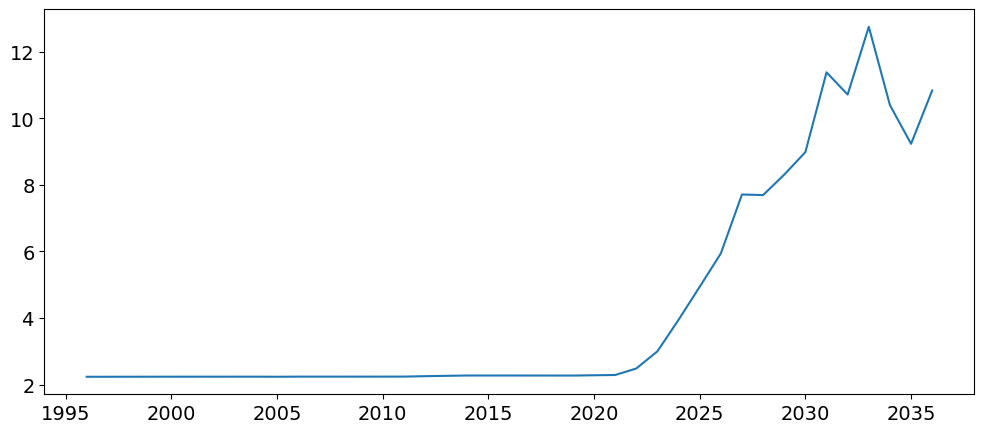

In [48]:
plt.plot(deg_df.TOTAL_to_base_ratio)

In [50]:
deg_df.TOTAL_to_base_ratio

year
1995          NaN
1996     2.235199
1997     2.235509
1998     2.236214
1999     2.236785
2000     2.237194
2001     2.237490
2002     2.237713
2003     2.237889
2004     2.238036
2005     2.235552
2006     2.239104
2007     2.239123
2008     2.239180
2009     2.239335
2010     2.239717
2011     2.240572
2012     2.252900
2013     2.263457
2014     2.273573
2015     2.273471
2016     2.273266
2017     2.272907
2018     2.272368
2019     2.271735
2020     2.280673
2021     2.288852
2022     2.483822
2023     3.000872
2024     3.947408
2025     4.939540
2026     5.942739
2027     7.713207
2028     7.695486
2029     8.310326
2030     8.986045
2031    11.383783
2032    10.716424
2033    12.752959
2034    10.399996
2035     9.235678
2036    10.837228
Name: TOTAL_to_base_ratio, dtype: float64

In [49]:
deg_df.to_csv('waste_cum_clean_togetherforSi&CdTe_2036.csv')

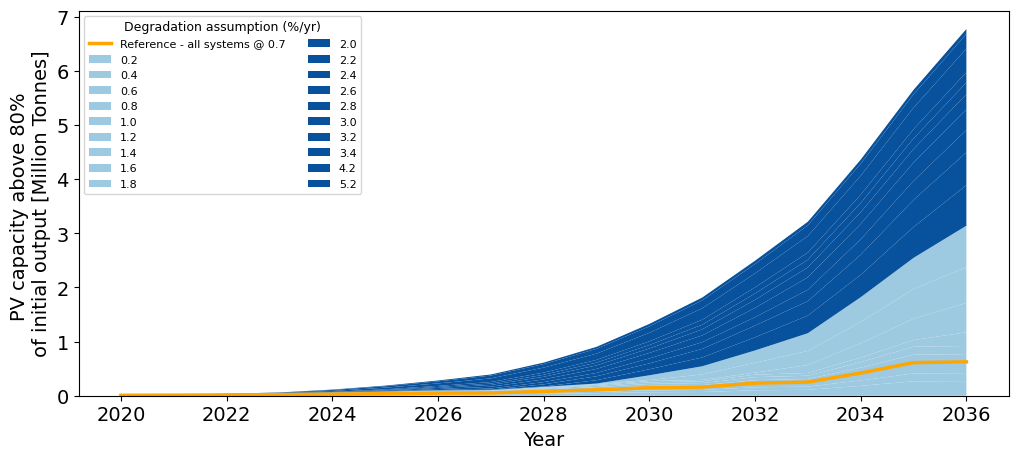

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# --- slice to start at 2020 ---
deg_df_2020 = deg_df.loc[deg_df.index >= 2020]

# --- pick only numeric degradation columns like '0.2', '0.4', ...
num_cols = []
num_vals = []
for c in deg_df_2020.columns:
    try:
        v = float(c)
        num_cols.append(c)
        num_vals.append(v)
    except (ValueError, TypeError):
        pass

# sort by numeric degradation value
order = np.argsort(num_vals)
num_cols = [num_cols[i] for i in order]
num_vals = [num_vals[i] for i in order]

# --- stacked data (convert to million tonnes) ---
Y = np.vstack([
    deg_df_2020[c].to_numpy() / 1e6
    for c in num_cols
])
x = deg_df_2020.index.to_numpy()

# --- colors: light vs dark blue split at 2.0 ---
light_blue = "#9ecae1"
dark_blue  = "#08519c"
colors = [light_blue if v < 2.0 else dark_blue for v in num_vals]

# --- plot ---
plt.figure()

# stacked degradation scenarios
plt.stackplot(
    x, Y,
    labels=[str(v) for v in num_vals],
    colors=colors
)

# base case line (orange), also in million tonnes
plt.plot(
    x,
    deg_df_2020["base"] / 1e6,
    linewidth=2.5,
    color="orange",
    label="Reference - all systems @ 0.7"
)

plt.xlabel("Year")
plt.ylabel("PV capacity above 80% \nof initial output [Million Tonnes]")
#plt.title("End-of-life PV under degradation scenarios vs base case")

# --- reorder legend so base appears first ---
handles, labels = plt.gca().get_legend_handles_labels()
base_idx = labels.index("Reference - all systems @ 0.7")
handles = [handles[base_idx]] + handles[:base_idx] + handles[base_idx+1:]
labels  = [labels[base_idx]]  + labels[:base_idx]  + labels[base_idx+1:]

plt.legend(handles, labels, loc="upper left", ncol=2, fontsize=8)


leg = plt.legend(
    handles,
    labels,
    title="Degradation assumption (%/yr)",
    loc="upper left",
    ncol=2,
    fontsize=8
)
leg.get_title().set_fontsize(9)


plt.show()


## PLOTS 

In [23]:
'Si_'+deg_parts[ii]

'Si_deg_0.2'

Text(0, 0.5, 'Yearly Installed Capacity [MW]')

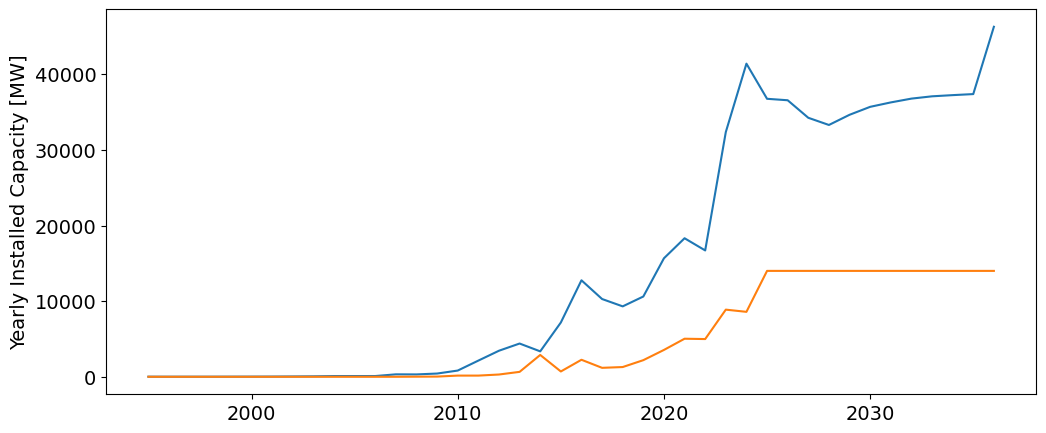

In [24]:
plt.plot(r1.scenario['base_Si'].dataIn_m.year, r1.scenario['base_Si'].dataIn_m['new_Installed_Capacity_[MW]'])
plt.plot(r1.scenario['base_CdTe'].dataIn_m.year, r1.scenario['base_CdTe'].dataIn_m['new_Installed_Capacity_[MW]'])
plt.ylabel('Yearly Installed Capacity [MW]')


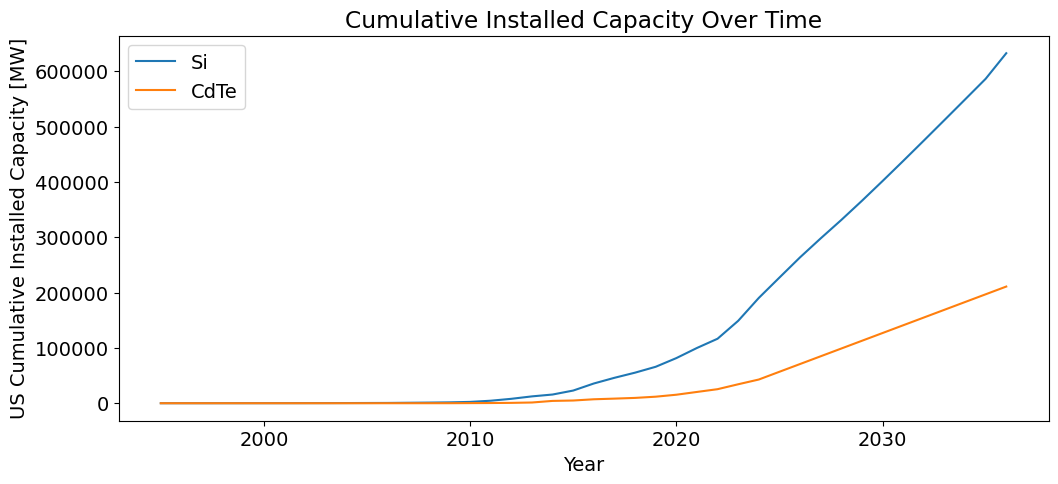

In [19]:
# Cumulative plot
plt.plot(r1.scenario['base_Si'].dataIn_m.year,
         r1.scenario['base_Si'].dataIn_m['new_Installed_Capacity_[MW]'].cumsum(),
         label='Si')

plt.plot(r1.scenario['base_CdTe'].dataIn_m.year,
         r1.scenario['base_CdTe'].dataIn_m['new_Installed_Capacity_[MW]'].cumsum(),
         label='CdTe')

plt.legend()
plt.xlabel('Year')
plt.ylabel('US Cumulative Installed Capacity [MW]')
plt.title('Cumulative Installed Capacity Over Time')
plt.show()


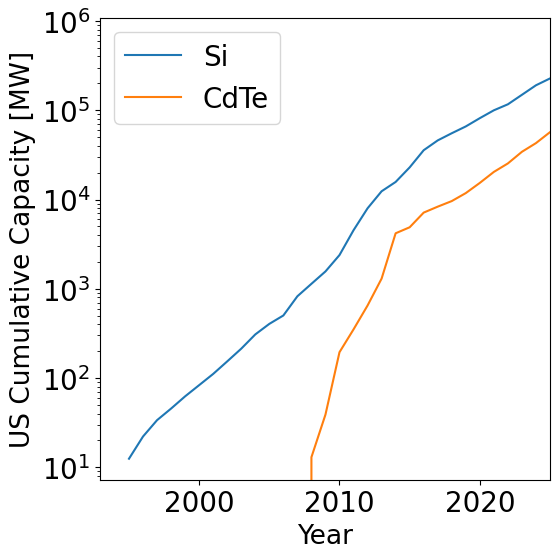

In [41]:
plt.figure(figsize=(6, 6))  # square-ish figure

plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 19,
    'axes.titlesize': 10,
    'legend.fontsize': 20
})


# Cumulative plot
plt.plot(
    r1.scenario['base_Si'].dataIn_m.year,
    r1.scenario['base_Si'].dataIn_m['new_Installed_Capacity_[MW]'].cumsum(),
    label='Si'
)

plt.plot(
    r1.scenario['base_CdTe'].dataIn_m.year,
    r1.scenario['base_CdTe'].dataIn_m['new_Installed_Capacity_[MW]'].cumsum(),
    label='CdTe'
)

plt.yscale('log')
plt.xlim(right=2025)

plt.legend()
plt.xlabel('Year')
plt.ylabel('US Cumulative Capacity [MW]')
#plt.title('Cumulative Installed Capacity Over Time')

plt.tight_layout()
plt.show()


In [25]:
r1.scenario['base_Si'].dataIn_m.year

0     1995
1     1996
2     1997
3     1998
4     1999
5     2000
6     2001
7     2002
8     2003
9     2004
10    2005
11    2006
12    2007
13    2008
14    2009
15    2010
16    2011
17    2012
18    2013
19    2014
20    2015
21    2016
22    2017
23    2018
24    2019
25    2020
26    2021
27    2022
28    2023
29    2024
30    2025
31    2026
32    2027
33    2028
34    2029
35    2030
36    2031
37    2032
38    2033
39    2034
40    2035
41    2036
Name: year, dtype: int64

In [29]:
r1.scenario['base_Si'].dataIn_m['new_Installed_Capacity_[MW]']
#20.926667 MW
#8586.216928 + 41399.161240

0        12.500000
1         9.667667
2        11.622000
3        11.781000
4        16.884667
5        20.926667
6        27.985000
7        42.476000
8        59.745000
9        94.752000
10       96.408474
11       97.860967
12      322.484799
13      312.318223
14      427.350690
15      822.991246
16     2139.992039
17     3444.579071
18     4395.160625
19     3359.898582
20     7175.384168
21    12757.064290
22    10280.616150
23     9308.764457
24    10612.961920
25    15667.380030
26    18315.535440
27    16704.296760
28    32358.148920
29    41399.161240
30    36752.716250
31    36560.119160
32    34242.282990
33    33292.165820
34    34637.589200
35    35689.397890
36    36273.855030
37    36776.375440
38    37080.163210
39    37237.220250
40    37375.394750
41    46274.579490
Name: new_Installed_Capacity_[MW], dtype: float64

In [26]:
# PVRW

In [27]:
main_results.keys()

Index(['WasteEOL_Module_Sim1_base_Si_[Tonnes]',
       'WasteEOL_Module_Sim1_base_CdTe_[Tonnes]',
       'WasteEOL_Module_Sim1_Si_deg_TOTAL_[Tonnes]',
       'WasteEOL_Module_Sim1_CdTe_deg_TOTAL_[Tonnes]'],
      dtype='object')

In [28]:
df = main_results[[
    "WasteEOL_Module_Sim1_base_Si_[Tonnes]",
    "WasteEOL_Module_Sim1_base_CdTe_[Tonnes]",
    "WasteEOL_Module_Sim1_Si_deg_TOTAL_[Tonnes]",
    "WasteEOL_Module_Sim1_CdTe_deg_TOTAL_[Tonnes]"
]].assign(
    base_TOTAL=lambda x: x.iloc[:, 0] + x.iloc[:, 1],
    deg_TOTAL=lambda x: x.iloc[:, 2] + x.iloc[:, 3],
)[["base_TOTAL", "deg_TOTAL"]]


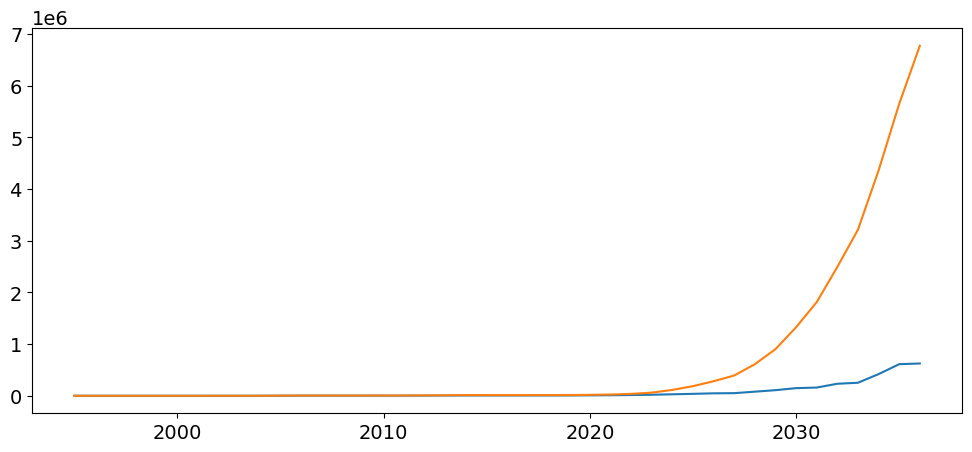

In [29]:
plt.plot(df)

In [30]:
df["deg_to_base_ratio"] = df["deg_TOTAL"] / df["base_TOTAL"]


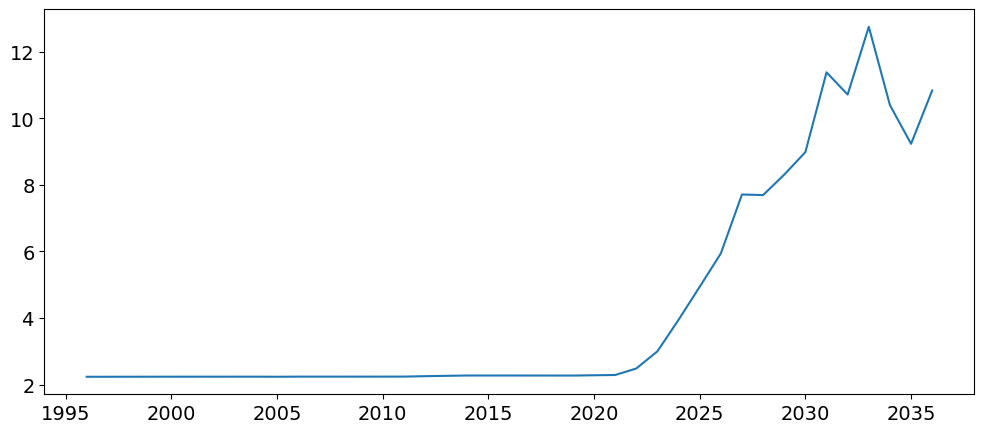

In [32]:
plt.plot(df.deg_to_base_ratio)

In [34]:
df["deg_increase_pct"] = (
    df["deg_TOTAL"] / df["base_TOTAL"] - 1
) * 100

In [ ]:
plt.plot(df.deg_increase_pct)